In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
oil_prices = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_prices['date'] = pd.to_datetime(oil_prices['date'])

oil_futures = pd.read_csv('../data/processed/Oil/oil_futures.csv')
oil_futures['date'] = pd.to_datetime(oil_futures['date'])

oil_companies = pd.read_csv('../data/processed/Oil/oilcompanies.csv')
oil_companies['date'] = pd.to_datetime(oil_companies['date'])

df = oil_prices.merge(oil_futures, on='date',how='left')
df = df.merge(oil_companies, on='date', how='left')

df.set_index('date',inplace=True)
df.head()

,Brent,WTI,OPEC_basket,Dubai_Crude,Brent_1m,Brent_3m,Brent_6m,Brent_12m,Brent_24m,ExxonMobile,...,ConocoPhillips,BP,SaudiAramco,Petrobras,Ecopetrol,Petrochina,Sinopec,Equinor,Nyse_Oil_Index,OccidentalPetroleum
date,,,,,,,,,,,,,,,,,,,,,
1999-12-31,25.73,25.60,23.89,23.30,25.08,23.18,21.20,19.26,NaN,40.2813,...,17.9145,622.5,NaN,5.00,NaN,NaN,2.65,NaN,503.00,10.3718
2000-01-03,25.73,25.60,23.89,22.43,25.08,23.18,21.20,19.26,NaN,39.0938,...,17.2713,622.5,NaN,4.90,NaN,NaN,2.65,NaN,487.13,9.9821
2000-01-04,24.64,25.55,23.42,22.40,24.39,22.86,20.94,19.20,NaN,38.4063,...,16.9378,596.0,NaN,4.64,NaN,NaN,2.75,NaN,477.09,9.7723
2000-01-05,23.59,24.93,22.91,22.22,23.73,22.50,20.69,18.96,NaN,40.5000,...,16.6281,596.0,NaN,4.69,NaN,NaN,2.77,NaN,485.08,9.8322
2000-01-06,23.55,24.78,22.74,22.10,23.62,22.39,20.62,18.98,NaN,42.5000,...,17.1998,602.0,NaN,4.65,NaN,NaN,3.05,NaN,498.79,10.1020


In [4]:
state_owned = ['SaudiAramco', 'Petrobras', 'Ecopetrol', 
               'Petrochina', 'Sinopec', 'Equinor']
private = ['ExxonMobile', 'Chevron', 'Shell', 'TotalEnergies', 
           'ConocoPhillips', 'BP', 'OccidentalPetroleum']
index_col = ['Nyse_Oil_Index']

df['futures_spread'] = (df['Brent_12m'] -df['Brent']) / df['Brent']

df_monthly = df.resample('ME').last()

all_equities = state_owned + private + index_col
for col in all_equities:
    df_monthly[f'{col}_ret'] = np.log(df_monthly[col] / df_monthly[col].shift(1))


df_monthly['futures_spread_chg'] = df_monthly['futures_spread'].diff()

# Also compute Brent spot return for control
df_monthly['brent_ret'] = np.log(df_monthly['Brent'] / df_monthly['Brent'].shift(1))


df_monthly['log_curve_ratio'] = np.log(df_monthly['Brent_12m'] / df_monthly['Brent'])
df_monthly['d_log_curve_ratio'] = df_monthly['log_curve_ratio'].diff()

# Drop first row (NaN from returns)
df_monthly = df_monthly.iloc[1:]



In [5]:
import statsmodels.api as sm

colors_state = plt.cm.Set1(np.linspace(0, 1, max(len(state_owned), 2)))
colors_private = plt.cm.Set2(np.linspace(0, 1, max(len(private), 2)))
colors_index = ['#2c3e50']

# ── Residualize: partial out Brent returns ────────────────────
for comp in all_equities:
    ret_col = f'{comp}_ret'
    mask = df_monthly[['d_log_curve_ratio', 'brent_ret', ret_col]].dropna().index
    
    y = df_monthly.loc[mask, ret_col]
    X = sm.add_constant(df_monthly.loc[mask, 'brent_ret'])
    df_monthly.loc[mask, f'{comp}_ret_resid'] = sm.OLS(y, X).fit().resid
    
    y2 = df_monthly.loc[mask, 'd_log_curve_ratio']
    df_monthly.loc[mask, 'spread_chg_resid'] = sm.OLS(y2, X).fit().resid


def make_panel(ax, companies, colors, title, spread_col='d_log_curve_ratio', ret_suffix='_ret'):
    """Plot scatter + pooled OLS line for a group of companies."""
    all_x, all_y = [], []
    
    for i, comp in enumerate(companies):
        ret_col = f'{comp}{ret_suffix}'
        mask = df_monthly[[spread_col, ret_col]].dropna().index
        x = df_monthly.loc[mask, spread_col].values
        y = df_monthly.loc[mask, ret_col].values
        
        ax.scatter(x, y, alpha=0.35, s=18, color=colors[i],
                   label=comp, edgecolors='none', zorder=2)
        all_x.extend(x)
        all_y.extend(y)
    
    all_x, all_y = np.array(all_x), np.array(all_y)
    
    valid = ~(np.isnan(all_x) | np.isnan(all_y))
    slope, intercept, r, p, se = stats.linregress(all_x[valid], all_y[valid])
    
    x_line = np.linspace(np.nanpercentile(all_x, 1), np.nanpercentile(all_x, 99), 100)
    ax.plot(x_line, intercept + slope * x_line, 'k-', lw=2, zorder=5)
    
    n = valid.sum()
    sign = '+' if slope >= 0 else ''
    ax.text(0.03, 0.97,
            f'β = {sign}{slope:.4f}\n'
            f'R² = {r**2:.3f}\n'
            f'p = {p:.4f}\n'
            f'n = {n:,}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='gray', alpha=0.9))
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(0, color='gray', lw=0.5, ls='--', zorder=1)
    ax.axvline(0, color='gray', lw=0.5, ls='--', zorder=1)
    ax.legend(fontsize=7, loc='lower right', framealpha=0.8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    
    return slope, r**2, p, n



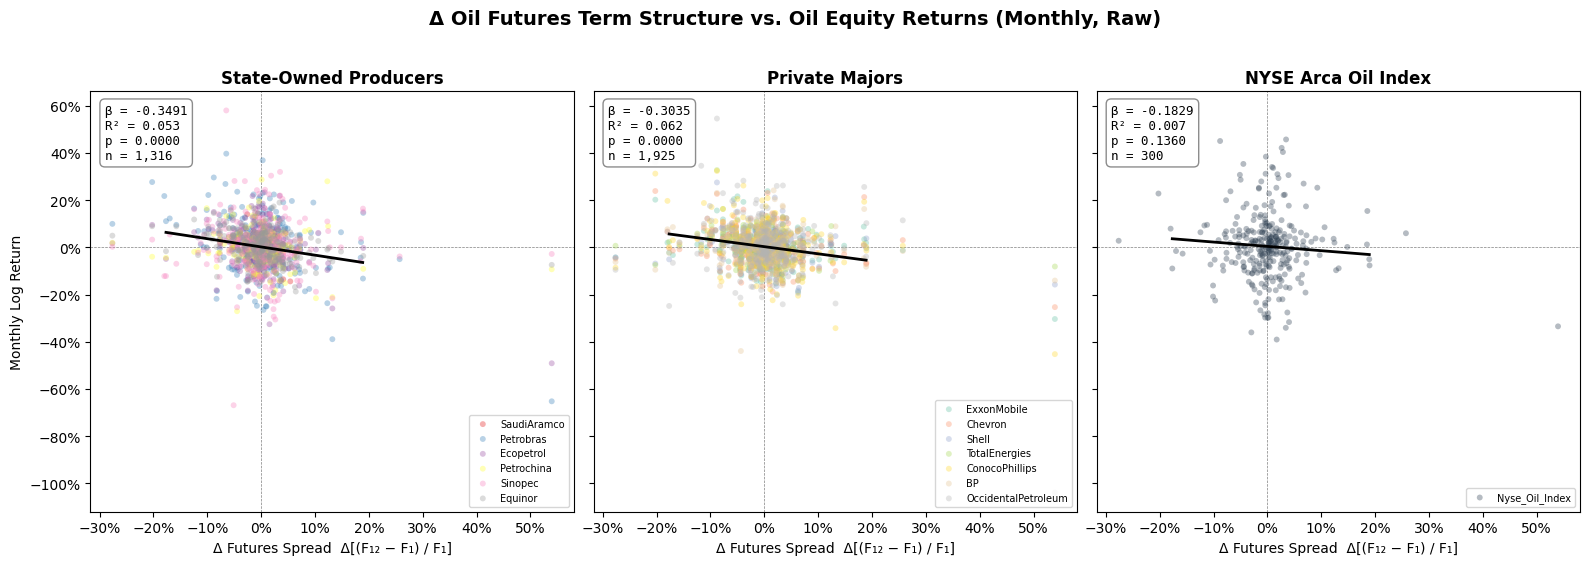

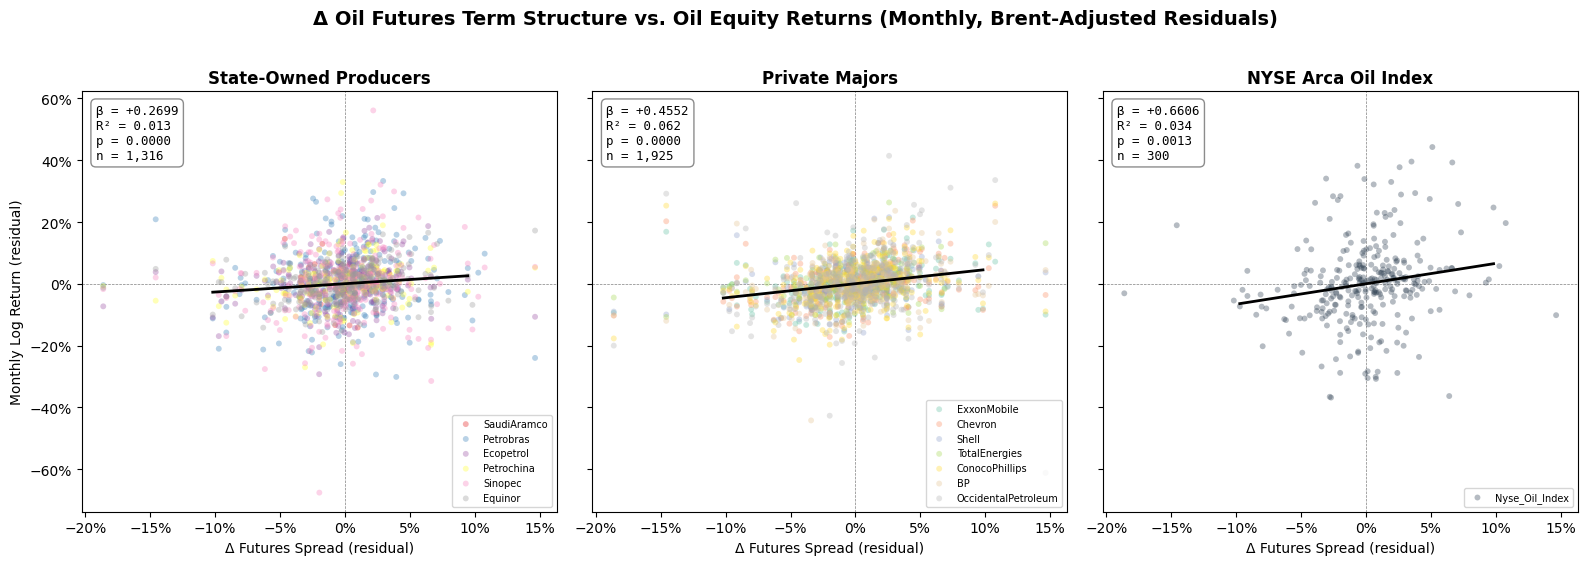

In [6]:
# ── Figure 1: Raw scatter (no Brent control) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
fig.suptitle('Δ Oil Futures Term Structure vs. Oil Equity Returns (Monthly, Raw)',
             fontsize=14, fontweight='bold', y=1.02)

make_panel(axes[0], state_owned, colors_state, 'State-Owned Producers',
           spread_col='d_log_curve_ratio', ret_suffix='_ret')
make_panel(axes[1], private, colors_private, 'Private Majors',
           spread_col='d_log_curve_ratio', ret_suffix='_ret')
make_panel(axes[2], index_col, colors_index, 'NYSE Arca Oil Index',
           spread_col='d_log_curve_ratio', ret_suffix='_ret')

axes[0].set_ylabel('Monthly Log Return')
axes[0].set_xlabel('Δ Futures Spread  Δ[(F₁₂ − F₁) / F₁]')
axes[1].set_xlabel('Δ Futures Spread  Δ[(F₁₂ − F₁) / F₁]')
axes[2].set_xlabel('Δ Futures Spread  Δ[(F₁₂ − F₁) / F₁]')
for ax in axes[1:]:
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


# ── Figure 2: Residualized scatter (Brent partialled out) ────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
fig.suptitle('Δ Oil Futures Term Structure vs. Oil Equity Returns (Monthly, Brent-Adjusted Residuals)',
             fontsize=14, fontweight='bold', y=1.02)

make_panel(axes[0], state_owned, colors_state, 'State-Owned Producers',
           spread_col='spread_chg_resid', ret_suffix='_ret_resid')
make_panel(axes[1], private, colors_private, 'Private Majors',
           spread_col='spread_chg_resid', ret_suffix='_ret_resid')
make_panel(axes[2], index_col, colors_index, 'NYSE Arca Oil Index',
           spread_col='spread_chg_resid', ret_suffix='_ret_resid')

axes[0].set_ylabel('Monthly Log Return (residual)')
axes[0].set_xlabel('Δ Futures Spread (residual)')
axes[1].set_xlabel('Δ Futures Spread (residual)')
axes[2].set_xlabel('Δ Futures Spread (residual)')
for ax in axes[1:]:
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Regression

In [7]:
import statsmodels.api as sm

reg_results = []

for comp in all_equities:
    ret_col = f'{comp}_ret'
    cols = ['d_log_curve_ratio', 'brent_ret', ret_col]
    sub = df_monthly[cols].dropna()
    
    if len(sub) < 30:
        continue
    
    y = sub[ret_col]
    
    # Model 1: Bivariate (spread only)
    X1 = sm.add_constant(sub[['d_log_curve_ratio']])
    m1 = sm.OLS(y, X1).fit(cov_type='HC1')
    
    # Model 2: With Brent spot return control
    X2 = sm.add_constant(sub[['d_log_curve_ratio', 'brent_ret']])
    m2 = sm.OLS(y, X2).fit(cov_type='HC1')
    
    group = ('State-Owned' if comp in state_owned 
             else 'Private' if comp in private 
             else 'Index')
    
    reg_results.append({
        'Company': comp,
        'Group': group,
        'N': len(sub),
        'β_spread': m1.params['d_log_curve_ratio'],
        'p_spread': m1.pvalues['d_log_curve_ratio'],
        'R²_spread': m1.rsquared,
        'β_spread|brent': m2.params['d_log_curve_ratio'],
        'p_spread|brent': m2.pvalues['d_log_curve_ratio'],
        'β_brent': m2.params['brent_ret'],
        'R²_full': m2.rsquared,
    })

reg_df = pd.DataFrame(reg_results)

# Print formatted table
def stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    if p < 0.10: return '†'
    return ''

print(f"\n{'Company':<22} {'Group':<12} {'N':>4}  "
      f"{'β_spread':>10} {'':>4}  {'R²':>6}  "
      f"{'β_spread|Brent':>14} {'':>4}  {'β_Brent':>8}  {'R²_full':>7}")
print("-"*100)

for _, row in reg_df.iterrows():
    s1 = stars(row['p_spread'])
    s2 = stars(row['p_spread|brent'])
    print(f"{row['Company']:<22} {row['Group']:<12} {row['N']:>4}  "
          f"{row['β_spread']:>10.4f} {s1:<4}  {row['R²_spread']:>6.3f}  "
          f"{row['β_spread|brent']:>14.4f} {s2:<4}  "
          f"{row['β_brent']:>8.4f}  {row['R²_full']:>7.3f}")

# ── 7. Pooled regressions by group ───────────────────────────
print("\n" + "="*70)
print("POOLED REGRESSIONS BY GROUP")
print("="*70)

for group_name, group_list in [('State-Owned', state_owned), 
                                ('Private', private)]:
    # Stack all companies in group
    frames = []
    for comp in group_list:
        ret_col = f'{comp}_ret'
        sub = df_monthly[['futures_spread_chg', 'brent_ret', ret_col]].dropna()
        sub = sub.rename(columns={ret_col: 'equity_ret'})
        sub['company'] = comp
        frames.append(sub)
    
    if not frames:
        continue
    
    pooled = pd.concat(frames, ignore_index=True)
    y = pooled['equity_ret']
    X = sm.add_constant(pooled[['futures_spread_chg', 'brent_ret']])
    m = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': pooled['company']})
    
    print(f"\n── {group_name} (n={len(pooled)}, companies={len(group_list)}) ──")
    print(f"  futures_spread_chg: β={m.params['futures_spread_chg']:.4f}, "
          f"t={m.tvalues['futures_spread_chg']:.2f}, "
          f"p={m.pvalues['futures_spread_chg']:.4f}{stars(m.pvalues['futures_spread_chg'])}")
    print(f"  brent_ret:      β={m.params['brent_ret']:.4f}, "
          f"t={m.tvalues['brent_ret']:.2f}, "
          f"p={m.pvalues['brent_ret']:.4f}{stars(m.pvalues['brent_ret'])}")
    print(f"  R² = {m.rsquared:.3f}")


Company                Group           N    β_spread           R²  β_spread|Brent        β_Brent  R²_full
----------------------------------------------------------------------------------------------------
Petrobras              State-Owned   300     -0.6359 ***    0.130          0.2300         0.6304    0.251
Ecopetrol              State-Owned   205     -0.5916 ***    0.162          0.2987 †       0.6083    0.365
Petrochina             State-Owned   205     -0.1509 †      0.015          0.2851 *       0.2979    0.087
Sinopec                State-Owned   300     -0.0621        0.001          0.2380         0.2185    0.017
Equinor                State-Owned   282     -0.3075 ***    0.078          0.3754 **      0.4785    0.295
ExxonMobile            Private       300     -0.2244 *      0.056          0.3822 **      0.4416    0.258
Chevron                Private       300     -0.2326 **     0.052          0.4297 **      0.4822    0.263
Shell                  Private       233     -0.19

## Looking at CDS

In [8]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

# ══════════════════════════════════════════════════════════════
# 1. Load CCA panel (weekly)
# ══════════════════════════════════════════════════════════════
cca = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca['date'] = pd.to_datetime(cca['date'])
cca.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)

study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia', 'Indonesia',
    'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand'
]
cca = cca[cca['country'].isin(study_sovereigns)].copy()

# ══════════════════════════════════════════════════════════════
# 2. Load oil spot + futures
# ══════════════════════════════════════════════════════════════
oil_spot = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_spot['date'] = pd.to_datetime(oil_spot['date'])
oil_spot = oil_spot.set_index('date')

oil_futures = pd.read_csv('../data/processed/Oil/oil_futures.csv')
oil_futures['date'] = pd.to_datetime(oil_futures['date'])
oil_futures = oil_futures.set_index('date')

oil = oil_spot.join(oil_futures, how='inner')
oil = oil.resample('W-FRI').last()
oil['Oil_ret'] = np.log(oil['Brent'] / oil['Brent'].shift(1))
oil.index.name = 'date'
oil_merge = oil[['Oil_ret']].reset_index()

# ══════════════════════════════════════════════════════════════
# 3. Load VIX
# ══════════════════════════════════════════════════════════════
vix = pd.read_csv('../data/processed/Macroeconomic_variables/VIXCLS.csv')
vix['Date'] = pd.to_datetime(vix['Date'])
vix['VIXCLS'] = pd.to_numeric(vix['VIXCLS'], errors='coerce')
vix = vix.set_index('Date').resample('W-FRI').last()
vix['VIX_chg'] = vix['VIXCLS'].diff()
vix.index.name = 'date'
vix_merge = vix[['VIX_chg']].reset_index()

# ══════════════════════════════════════════════════════════════
# 4. Load macro controls (DXY, UST)
# ══════════════════════════════════════════════════════════════
macro = pd.read_csv('../data/processed/Macroeconomic_variables/macro_risk_variables.csv',
                     parse_dates=['Date'], index_col='Date')
macro = macro.resample('W-FRI').last()
macro['UST10Y_chg'] = macro['UST10Y'].diff()
macro['DXY_chg'] = macro['DXY'].diff()
macro.index.name = 'date'
macro_merge = macro[['UST10Y_chg', 'DXY_chg']].reset_index()

# ══════════════════════════════════════════════════════════════
# 5. Build panel
# ══════════════════════════════════════════════════════════════
reg_panel = cca.copy().sort_values(['country', 'date'])

reg_panel['d_cds'] = reg_panel.groupby('country')['cds_spread'].transform(lambda x: np.log(x).diff())
reg_panel['FX_ret'] = reg_panel.groupby('country')['fx_rate'].transform(lambda x: np.log(x).diff())
reg_panel['MSCI_ret'] = reg_panel.groupby('country')['msci_index'].transform(lambda x: np.log(x).diff())

oil_exporters = ['Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar',
                 'Colombia', 'Mexico', 'Brazil', 'Egypt', 'Malaysia']
reg_panel['oil_exporter'] = reg_panel['country'].isin(oil_exporters).astype(int)

reg_panel = reg_panel.merge(oil_merge, on='date', how='left')
reg_panel = reg_panel.merge(vix_merge, on='date', how='left')
reg_panel = reg_panel.merge(macro_merge, on='date', how='left')

In [9]:
# ── Curve ratios at different tenors ─────────────────────────
oil['log_curve_1m'] = np.log(oil['Brent_1m'] / oil['Brent'])
oil['d_log_curve_1m'] = oil['log_curve_1m'].diff()

oil['log_curve_3m'] = np.log(oil['Brent_3m'] / oil['Brent'])
oil['d_log_curve_3m'] = oil['log_curve_3m'].diff()

oil['log_curve_6m'] = np.log(oil['Brent_6m'] / oil['Brent'])
oil['d_log_curve_6m'] = oil['log_curve_6m'].diff()

oil['log_curve_12m'] = np.log(oil['Brent_12m'] / oil['Brent'])
oil['d_log_curve_12m'] = oil['log_curve_12m'].diff()

oil['log_curve_24m'] = np.log(oil['Brent_24m'] / oil['Brent'])
oil['d_log_curve_24m'] = oil['log_curve_24m'].diff()

curve_cols = ['log_curve_1m','log_curve_3m','log_curve_6m','log_curve_12m','log_curve_24m','d_log_curve_1m', 'd_log_curve_3m', 'd_log_curve_6m', 'd_log_curve_12m', 'd_log_curve_24m']
curve_merge = oil[curve_cols].reset_index()

for col in curve_cols:
    if col in reg_panel.columns:
        reg_panel.drop(columns=[col], inplace=True)
reg_panel = reg_panel.merge(curve_merge, on='date', how='left')

# ── Run same spec for each tenor ─────────────────────────────
controls = ['VIX_chg', 'FX_ret', 'MSCI_ret', 'UST10Y_chg', 'DXY_chg']

for tenor, tlabel in [('d_log_curve_1m', '1m'),('d_log_curve_3m', '3m'),('d_log_curve_6m', '6m'), ('d_log_curve_12m', '12m'), ('d_log_curve_24m', '24m')]:
    reg_panel[f'Curve_{tlabel}_x_Exp'] = reg_panel[tenor] * reg_panel['oil_exporter']
    
    ivs = [tenor, f'Curve_{tlabel}_x_Exp'] + controls
    sub = reg_panel.dropna(subset=['d_cds'] + ivs).copy()
    sub = sub.set_index(['country', 'date'])
    
    y = sub['d_cds']
    X = sub[ivs]
    
    mod = PanelOLS(y, X, entity_effects=True
          ).fit(cov_type='clustered', cluster_entity=True)
    
    b_base = mod.params[tenor]
    t_base = mod.tstats[tenor]
    p_base = mod.pvalues[tenor]
    b_int = mod.params[f'Curve_{tlabel}_x_Exp']
    t_int = mod.tstats[f'Curve_{tlabel}_x_Exp']
    p_int = mod.pvalues[f'Curve_{tlabel}_x_Exp']
    
    sb = '***' if p_base<0.01 else '**' if p_base<0.05 else '*' if p_base<0.1 else ''
    si = '***' if p_int<0.01 else '**' if p_int<0.05 else '*' if p_int<0.1 else ''
    
    print(f"\n  Tenor: {tlabel}")
    print(f"    Base (non-exp):  β={b_base:>7.3f}{sb:<3} t={t_base:>6.2f}  p={p_base:.4f}")
    print(f"    Interaction:     β={b_int:>7.3f}{si:<3} t={t_int:>6.2f}  p={p_int:.4f}")
    print(f"    Total (exp):     β={b_base+b_int:>7.3f}")
    print(f"    R²={mod.rsquared:.4f}  N={int(mod.nobs)}")


  Tenor: 1m
    Base (non-exp):  β=  0.259*** t=  7.87  p=0.0000
    Interaction:     β= -0.117*   t= -1.71  p=0.0870
    Total (exp):     β=  0.142
    R²=0.2921  N=9741

  Tenor: 3m
    Base (non-exp):  β= -0.140*** t= -3.01  p=0.0026
    Interaction:     β=  0.236*** t=  3.51  p=0.0004
    Total (exp):     β=  0.096
    R²=0.2919  N=9741

  Tenor: 6m
    Base (non-exp):  β= -0.170*** t= -4.39  p=0.0000
    Interaction:     β=  0.220*** t=  4.24  p=0.0000
    Total (exp):     β=  0.051
    R²=0.2927  N=9741

  Tenor: 12m
    Base (non-exp):  β= -0.102*** t= -3.19  p=0.0014
    Interaction:     β=  0.183*** t=  4.48  p=0.0000
    Total (exp):     β=  0.081
    R²=0.2924  N=9741

  Tenor: 24m
    Base (non-exp):  β= -0.030    t= -1.09  p=0.2761
    Interaction:     β=  0.138*** t=  3.82  p=0.0001
    Total (exp):     β=  0.108
    R²=0.2925  N=9741


In [10]:
controls = ['VIX_chg', 'FX_ret', 'MSCI_ret', 'UST10Y_chg', 'DXY_chg']

for tenor, tlabel in [('d_log_curve_1m', '1m'),('d_log_curve_3m', '3m'),('d_log_curve_6m', '6m'), ('d_log_curve_12m', '12m'), ('d_log_curve_24m', '24m')]:
    
    ivs = [tenor] + controls
    
    print(f"\n{'='*60}")
    print(f"Tenor: {tlabel}")
    print(f"{'='*60}")
    
    for group, glabel in [(True, 'Exporters'), (False, 'Importers')]:
        sub = reg_panel[reg_panel['oil_exporter'] == group].copy()
        sub = sub.dropna(subset=['d_cds'] + ivs)
        sub = sub.set_index(['country', 'date'])
        
        y = sub['d_cds']
        X = sub[ivs]
        
        mod = PanelOLS(y, X, entity_effects=True
              ).fit(cov_type='clustered', cluster_entity=True)
        
        b = mod.params[tenor]
        t = mod.tstats[tenor]
        p = mod.pvalues[tenor]
        
        sig = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        
        print(f"  {glabel:<12} β={b:>7.3f}{sig:<3} t={t:>6.2f}  p={p:.4f}  R²={mod.rsquared:.4f}  N={int(mod.nobs)}")


Tenor: 1m
  Exporters    β=  0.143**  t=  2.21  p=0.0273  R²=0.2688  N=5157
  Importers    β=  0.257*** t=  8.13  p=0.0000  R²=0.3221  N=4584

Tenor: 3m
  Exporters    β=  0.106**  t=  2.24  p=0.0248  R²=0.2689  N=5157
  Importers    β= -0.149*** t= -3.18  p=0.0015  R²=0.3218  N=4584

Tenor: 6m
  Exporters    β=  0.064    t=  1.62  p=0.1043  R²=0.2687  N=5157
  Importers    β= -0.183*** t= -4.64  p=0.0000  R²=0.3240  N=4584

Tenor: 12m
  Exporters    β=  0.096*** t=  3.03  p=0.0024  R²=0.2696  N=5157
  Importers    β= -0.116*** t= -3.79  p=0.0002  R²=0.3225  N=4584

Tenor: 24m
  Exporters    β=  0.124*** t=  4.58  p=0.0000  R²=0.2714  N=5157
  Importers    β= -0.046*   t= -1.96  p=0.0503  R²=0.3209  N=4584


In [11]:
controls = ['VIX_chg', 'FX_ret', 'MSCI_ret', 'UST10Y_chg', 'DXY_chg']

for tenor, tlabel in [('log_curve_1m', '1m'),('log_curve_3m', '3m'), ('log_curve_6m', '6m'), ('log_curve_12m', '12m'), ('log_curve_24m', '24m')]:
    
    ivs = [tenor] + controls
    
    print(f"\n{'='*60}")
    print(f"Tenor: {tlabel}")
    print(f"{'='*60}")
    
    for group, glabel in [(True, 'Exporters'), (False, 'Importers')]:
        sub = reg_panel[reg_panel['oil_exporter'] == group].copy()
        sub = sub.dropna(subset=['d_cds'] + ivs)
        sub = sub.set_index(['country', 'date'])
        
        y = sub['d_cds']
        X = sub[ivs]
        
        mod = PanelOLS(y, X, entity_effects=True
              ).fit(cov_type='clustered', cluster_entity=True)
        
        b = mod.params[tenor]
        t = mod.tstats[tenor]
        p = mod.pvalues[tenor]
        
        sig = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        
        print(f"  {glabel:<12} β={b:>7.3f}{sig:<3} t={t:>6.2f}  p={p:.4f}  R²={mod.rsquared:.4f}  N={int(mod.nobs)}")


Tenor: 1m
  Exporters    β=  0.233*** t=  2.82  p=0.0048  R²=0.2690  N=5157
  Importers    β=  0.386*** t=  7.64  p=0.0000  R²=0.3225  N=4584

Tenor: 3m
  Exporters    β=  0.084*** t=  5.04  p=0.0000  R²=0.2695  N=5157
  Importers    β=  0.000    t=  0.01  p=0.9900  R²=0.3205  N=4584

Tenor: 6m
  Exporters    β=  0.037*** t=  3.94  p=0.0001  R²=0.2691  N=5157
  Importers    β= -0.007    t= -0.71  p=0.4747  R²=0.3205  N=4584

Tenor: 12m
  Exporters    β=  0.023*** t=  4.05  p=0.0001  R²=0.2691  N=5157
  Importers    β= -0.001    t= -0.23  p=0.8162  R²=0.3205  N=4584

Tenor: 24m
  Exporters    β=  0.015*** t=  4.32  p=0.0000  R²=0.2691  N=5157
  Importers    β=  0.002    t=  0.62  p=0.5363  R²=0.3205  N=4584


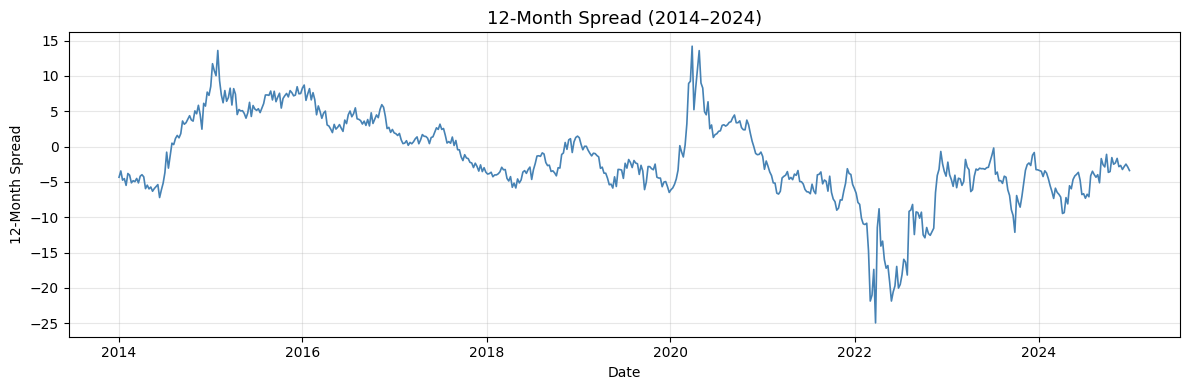

In [16]:
import matplotlib.pyplot as plt

oil['12_month_spread'] = oil['Brent_12m'] - oil['Brent']

mask = (oil.index >= '2014-01-01') & (oil.index <= '2024-12-31')
oil_filtered = oil.loc[mask]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(oil_filtered.index, oil_filtered['12_month_spread'], color='steelblue', linewidth=1.2)
ax.set_title('12-Month Spread (2014–2024)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('12-Month Spread')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [105]:
# ── Setup: prepare panel for predictive regressions ──────────

# Oil exporter dummy
oil_exporters = ['Saudi Arabia', 'Dubai', 'Abu Dhabi', 'Qatar',
                 'Colombia', 'Mexico', 'Brazil', 'Egypt', 'Malaysia']
panel['oil_exporter'] = panel['country'].isin(oil_exporters).astype(int)

# Merge oil data from df_monthly
oil_ts = df_monthly[['brent_ret', 'Brent_12m', 'log_curve_ratio']].copy()
oil_ts['brent_12m_ret'] = np.log(oil_ts['Brent_12m'] / oil_ts['Brent_12m'].shift(1))
oil_ts = oil_ts[['brent_ret', 'brent_12m_ret', 'log_curve_ratio']].copy()
oil_ts.index.name = 'date'
oil_ts = oil_ts.reset_index()
panel = panel.merge(oil_ts, on='date', how='left')

# LCL changes and forward cumulative changes
panel = panel.sort_values(['country', 'date'])
panel['d_log_lcl'] = panel.groupby('country')['LCL_usd'].transform(
    lambda x: np.log(x).diff()
)
panel['d_log_fx'] = panel.groupby('country')['fx_rate'].transform(
    lambda x: np.log(x).diff()
)
for h in [1, 3, 6]:
    panel[f'fwd_d_log_lcl_{h}'] = (
        panel.groupby('country')['LCL_usd']
        .transform(lambda x: np.log(x).shift(-h) - np.log(x))
    )

# CDS forward cumulative changes
for h in [1, 3, 6]:
    panel[f'fwd_d_cds_{h}'] = (
        panel.groupby('country')['cds_spread']
        .transform(lambda x: x.shift(-h) - x)
    )

print('Panel ready:', panel.shape)
print('Countries:', sorted(panel['country'].unique()))


ValueError: You are trying to merge on str and datetime64[us] columns for key 'date'. If you wish to proceed you should use pd.concat

In [10]:
# ── LCL predictive table: SpotRet + Fut12mRet → ΔlogLCL ─────
import statsmodels.api as sm

results = []
for country in sorted(panel['country'].unique()):
    c_data = panel[panel['country'] == country].copy()
    is_exp = int(c_data['oil_exporter'].iloc[0])
    for h in [1, 3, 6]:
        dep = f'fwd_d_log_lcl_{h}'
        ivs = ['brent_ret', 'brent_12m_ret']
        sub = c_data.dropna(subset=[dep] + ivs)
        if len(sub) < 30:
            continue
        y = sub[dep]
        X = sm.add_constant(sub[ivs])
        mod = sm.OLS(y, X).fit(cov_type='HC1')
        results.append({
            'Country': country, 'OilExp': is_exp, 'h': h,
            'β_spot': mod.params['brent_ret'],
            't_spot': mod.tvalues['brent_ret'],
            'β_fut12m': mod.params['brent_12m_ret'],
            't_fut12m': mod.tvalues['brent_12m_ret'],
            'R²': mod.rsquared, 'N': int(mod.nobs),
        })

res_df = pd.DataFrame(results)
for h in [1, 3, 6]:
    sub = res_df[res_df['h'] == h].sort_values(['OilExp', 'Country'], ascending=[False, True])
    print(f"\n{'='*90}")
    print(f"  h = {h} month{'s' if h>1 else ''}  —  ΔlogLCL(t→t+{h}) = α + β₁·SpotRet + β₂·Fut12mRet")
    print(f"{'='*90}")
    print(f"  {'Country':<16} {'OilExp':>6}  {'β_spot':>8} {'t':>6}  {'β_fut12m':>8} {'t':>6}  {'R²':>6}  {'N':>4}")
    print(f"  {'-'*80}")
    for _, r in sub.iterrows():
        s1 = '***' if abs(r['t_spot'])>2.58 else '**' if abs(r['t_spot'])>1.96 else '*' if abs(r['t_spot'])>1.65 else ''
        s2 = '***' if abs(r['t_fut12m'])>2.58 else '**' if abs(r['t_fut12m'])>1.96 else '*' if abs(r['t_fut12m'])>1.65 else ''
        print(f"  {r['Country']:<16} {r['OilExp']:>6}  {r['β_spot']:>8.4f}{s1:<3} {r['t_spot']:>6.2f}  "
              f"{r['β_fut12m']:>8.4f}{s2:<3} {r['t_fut12m']:>6.2f}  {r['R²']:>6.3f}  {r['N']:>4}")



  h = 1 month  —  ΔlogLCL(t→t+1) = α + β₁·SpotRet + β₂·Fut12mRet
  Country          OilExp    β_spot      t  β_fut12m      t      R²     N
  --------------------------------------------------------------------------------
  Abu Dhabi             1    0.0411*     1.80   -0.0530     -1.07   0.010   131
  Brazil                1    0.1644**    2.55   -0.2677***  -2.66   0.034   131
  Colombia              1    0.0652      0.99   -0.1019     -0.84   0.006   131
  Dubai                 1    0.0411*     1.80   -0.0530     -1.07   0.010   131
  Egypt                 1   -0.0815     -1.01    0.1582      1.11   0.004   131
  Malaysia              1   -0.0089     -0.26    0.0273      0.37   0.001   131
  Mexico                1    0.1481**    2.38   -0.2700**   -2.53   0.053   131
  Qatar                 1   -0.0418     -1.56   -0.0107     -0.20   0.036   131
  Saudi Arabia          1   -0.0759     -1.11    0.0523      0.55   0.016   131
  Chile                 0    0.1134*     1.81   -0.1826  

## Does the oil futures term structure predict future CDS changes?

$$\Delta CDS_{i,t \to t+h} = \alpha + \beta \cdot \text{FuturesTerm}_t + \varepsilon$$

In [11]:
sub = panel.dropna(subset=['d_cds', 'log_curve_ratio']).copy()

sub['curve_level_x_exp'] = sub['log_curve_ratio'] * sub['oil_exporter']
sub = sub.set_index(['country', 'date'])

mod = PanelOLS(
    sub['d_cds'],
    sub[['curve_level_x_exp']],
    entity_effects=True,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(mod.summary)

KeyError: ['d_cds']

In [12]:
panel

,country,date,Unnamed: 0,year,quarter,month,week,cds_spread,msci_index,monetary_base_mn_localcurr,...,brent_12m_ret,log_curve_ratio,d_log_lcl,d_log_fx,fwd_d_log_lcl_1,fwd_d_log_lcl_3,fwd_d_log_lcl_6,fwd_d_cds_1,fwd_d_cds_3,fwd_d_cds_6
0,Abu Dhabi,2014-01-31,13780,2014,1.0,1.0,5.0,56.32999,804.960,288.310000,...,-0.041062,-0.052704,NaN,NaN,-0.001135,0.009780,0.027971,-1.54000,-4.98999,-3.81000
1,Abu Dhabi,2014-02-28,13784,2014,1.0,2.0,9.0,54.78999,867.273,287.846000,...,0.025549,-0.045377,-0.001135,0.000000,0.019853,0.018374,0.027165,-0.97000,-9.99000,-3.50000
2,Abu Dhabi,2014-03-31,13788,2014,1.0,3.0,13.0,53.81999,895.321,297.840000,...,-0.008573,-0.034794,0.019853,0.000000,-0.008937,0.022046,0.026795,-2.47999,-8.02000,-2.06000
3,Abu Dhabi,2014-04-30,13792,2014,2.0,4.0,17.0,51.34000,1030.704,293.257000,...,-0.007184,-0.048962,-0.008937,0.000037,0.007458,0.018191,0.017895,-6.54001,1.17999,4.42999
4,Abu Dhabi,2014-05-31,13797,2014,2.0,5.0,22.0,44.79999,1043.794,296.941000,...,0.012202,-0.053140,0.007458,-0.000037,0.023525,0.008791,0.012988,1.00000,6.49000,15.87001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,Turkey,2024-08-31,13184,2024,3.0,8.0,35.0,265.75000,613.356,6157.194895,...,-0.042859,-0.067238,0.006572,0.033504,0.004577,-0.025198,NaN,2.12010,-14.63000,NaN
2240,Turkey,2024-09-30,13188,2024,3.0,9.0,39.0,267.87010,631.258,6175.969703,...,-0.040816,-0.015971,0.004577,0.001705,-0.013381,0.001096,NaN,3.37990,-10.19020,NaN
2241,Turkey,2024-10-31,13192,2024,4.0,10.0,43.0,271.25000,550.218,6099.357409,...,0.003806,-0.029253,-0.013381,0.003419,-0.016394,NaN,NaN,-20.13000,NaN,NaN
2242,Turkey,2024-11-30,13197,2024,4.0,11.0,48.0,251.12000,610.455,6067.888530,...,-0.016025,-0.045415,-0.016394,0.013793,0.030871,NaN,NaN,6.55990,NaN,NaN
